In [18]:
!pip install torchsummary

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import (
    train_test_split,
    ParameterGrid
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from torchsummary import summary

In [20]:
DATA_URL = "https://raw.githubusercontent.com/kashfihs/lab_5_220129/refs/heads/main/ANN/Datasets/heart.csv"

df = pd.read_csv(DATA_URL)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [22]:
target = 'target'
X = df.drop(target, axis=1)
y = df[target]

In [23]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

In [26]:
X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [27]:
X_train_tensor = torch.tensor(X_train)
X_val_tensor = torch.tensor(X_val)
X_test_tensor = torch.tensor(X_test)

y_train_tensor = torch.tensor(y_train).unsqueeze(1)
y_val_tensor = torch.tensor(y_val).unsqueeze(1)
y_test_tensor = torch.tensor(y_test).unsqueeze(1)

In [28]:
class ShallowNN(nn.Module):
    def __init__(self,input_dim,hidden_units,activation):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim,hidden_units),
            activation,
            nn.Linear(hidden_units,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [29]:
param_grid = {
    'hidden_units':[16,32,64],
    'activation':[nn.ReLU(),nn.Sigmoid()],
    'batch_size':[16,32]
}

In [30]:
class DeepNN(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [31]:
learning_rates = [0.01,0.001]

optimizers = ['Adam','SGD']

epochs = [50,100]

In [32]:
def train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=50):

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(epochs):

        # TRAIN
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predicted = (outputs >= 0.5).float()

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                val_loss_total += loss.item()

                predicted = (outputs >= 0.5).float()

                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss={train_loss:.4f} "
            f"Val Loss={val_loss:.4f} "
            f"Train Acc={train_acc:.4f} "
            f"Val Acc={val_acc:.4f}"
        )

    return history

In [33]:
batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [34]:
input_dim = X_train.shape[1]

shallow_model = ShallowNN(
    input_dim=input_dim,
    hidden_units=32,
    activation=nn.ReLU()
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    shallow_model.parameters(),
    lr=0.001
)

shallow_history = train_model(
    shallow_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=50
)

Epoch [1/50] Train Loss=0.6732 Val Loss=0.6319 Train Acc=0.6098 Val Acc=0.7500
Epoch [2/50] Train Loss=0.6065 Val Loss=0.5749 Train Acc=0.7332 Val Acc=0.7683
Epoch [3/50] Train Loss=0.5455 Val Loss=0.5250 Train Acc=0.7759 Val Acc=0.7622
Epoch [4/50] Train Loss=0.4927 Val Loss=0.4862 Train Acc=0.8018 Val Acc=0.7805
Epoch [5/50] Train Loss=0.4494 Val Loss=0.4606 Train Acc=0.8293 Val Acc=0.8049
Epoch [6/50] Train Loss=0.4155 Val Loss=0.4447 Train Acc=0.8277 Val Acc=0.8293
Epoch [7/50] Train Loss=0.3928 Val Loss=0.4374 Train Acc=0.8384 Val Acc=0.8293
Epoch [8/50] Train Loss=0.3750 Val Loss=0.4358 Train Acc=0.8521 Val Acc=0.8232
Epoch [9/50] Train Loss=0.3633 Val Loss=0.4386 Train Acc=0.8521 Val Acc=0.8232
Epoch [10/50] Train Loss=0.3541 Val Loss=0.4429 Train Acc=0.8582 Val Acc=0.8293
Epoch [11/50] Train Loss=0.3392 Val Loss=0.4470 Train Acc=0.8582 Val Acc=0.8354
Epoch [12/50] Train Loss=0.3343 Val Loss=0.4533 Train Acc=0.8582 Val Acc=0.8354
Epoch [13/50] Train Loss=0.3285 Val Loss=0.4577 T

In [35]:
deep_model = DeepNN(
    input_dim=input_dim
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    deep_model.parameters(),
    lr=0.001
)

deep_history = train_model(
    deep_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=100
)

Epoch [1/100] Train Loss=0.6664 Val Loss=0.6101 Train Acc=0.6799 Val Acc=0.8171
Epoch [2/100] Train Loss=0.5184 Val Loss=0.4401 Train Acc=0.8460 Val Acc=0.8537
Epoch [3/100] Train Loss=0.3750 Val Loss=0.4305 Train Acc=0.8445 Val Acc=0.8415
Epoch [4/100] Train Loss=0.3329 Val Loss=0.4461 Train Acc=0.8567 Val Acc=0.8598
Epoch [5/100] Train Loss=0.3221 Val Loss=0.4497 Train Acc=0.8720 Val Acc=0.8598
Epoch [6/100] Train Loss=0.3059 Val Loss=0.4548 Train Acc=0.8704 Val Acc=0.8659
Epoch [7/100] Train Loss=0.2949 Val Loss=0.4515 Train Acc=0.8826 Val Acc=0.8598
Epoch [8/100] Train Loss=0.2859 Val Loss=0.4454 Train Acc=0.8857 Val Acc=0.8720
Epoch [9/100] Train Loss=0.2679 Val Loss=0.4361 Train Acc=0.8933 Val Acc=0.8598
Epoch [10/100] Train Loss=0.2661 Val Loss=0.4354 Train Acc=0.8933 Val Acc=0.8659
Epoch [11/100] Train Loss=0.2544 Val Loss=0.4396 Train Acc=0.9024 Val Acc=0.8659
Epoch [12/100] Train Loss=0.2444 Val Loss=0.4155 Train Acc=0.9055 Val Acc=0.8659
Epoch [13/100] Train Loss=0.2398 Val 

In [36]:
def evaluate_model(model, X_test_tensor, y_test):

    model.eval()

    with torch.no_grad():

        probs = model(X_test_tensor)

        probs = probs.numpy().flatten()

        preds = (probs >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, preds)

    precision = precision_score(y_test, preds)

    recall = recall_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    auc = roc_auc_score(y_test, probs)

    cm = confusion_matrix(y_test, preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'cm': cm,
        'probs': probs,
        'preds': preds
    }

In [37]:
shallow_results = evaluate_model(
    shallow_model,
    X_test_tensor,
    y_test
)

deep_results = evaluate_model(
    deep_model,
    X_test_tensor,
    y_test
)

print(shallow_results)
print(deep_results)

{'accuracy': 0.8780487804878049, 'precision': 0.8571428571428571, 'recall': 0.9142857142857143, 'f1': 0.8847926267281107, 'auc': np.float64(0.953904761904762), 'cm': array([[84, 16],
       [ 9, 96]]), 'probs': array([7.80294230e-03, 3.39150280e-01, 1.56149722e-03, 7.17213273e-01,
       7.75768533e-02, 1.48017602e-02, 9.61449206e-01, 3.69014680e-01,
       9.94051278e-01, 3.39150280e-01, 5.51810324e-01, 9.23886538e-01,
       3.69014680e-01, 2.45751403e-02, 8.79331529e-01, 3.11640673e-03,
       6.72798976e-02, 1.37133058e-02, 4.53254521e-01, 9.83708203e-01,
       1.73702114e-03, 1.74062699e-02, 6.37276292e-01, 9.96250212e-01,
       1.85187176e-01, 9.95583117e-01, 6.67645931e-02, 2.45751403e-02,
       5.63892901e-01, 5.14173508e-03, 7.99858928e-01, 8.90280485e-01,
       8.37946236e-01, 9.86999691e-01, 2.10101414e-03, 4.58579212e-02,
       9.52396214e-01, 1.93984389e-01, 2.41414219e-01, 9.32609200e-01,
       1.42560212e-03, 9.81129706e-01, 6.12967372e-01, 9.32609200e-01,
       6

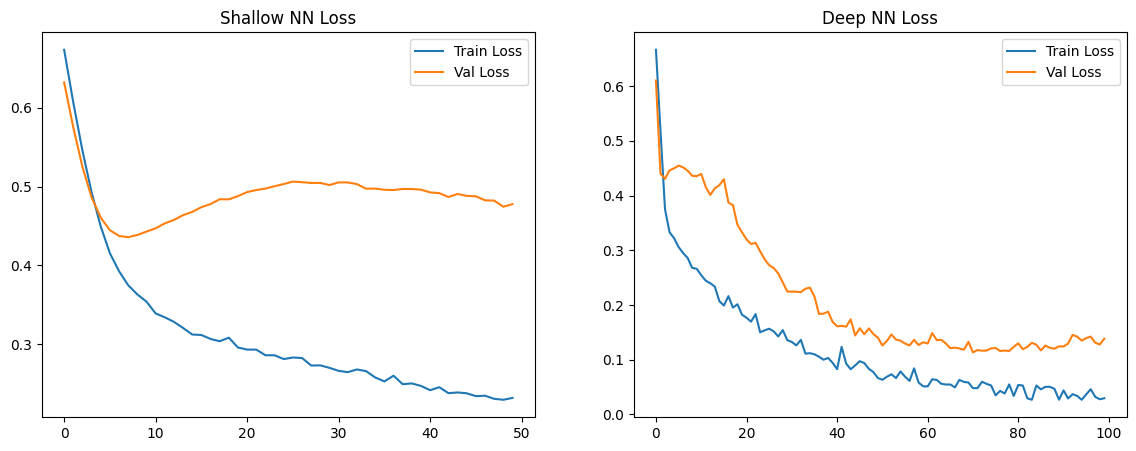

In [38]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].plot(shallow_history['train_loss'],label='Train Loss')
ax[0].plot(shallow_history['val_loss'],label='Val Loss')
ax[0].set_title('Shallow NN Loss')
ax[0].legend()

ax[1].plot(deep_history['train_loss'],label='Train Loss')
ax[1].plot(deep_history['val_loss'],label='Val Loss')
ax[1].set_title('Deep NN Loss')
ax[1].legend()

plt.show()

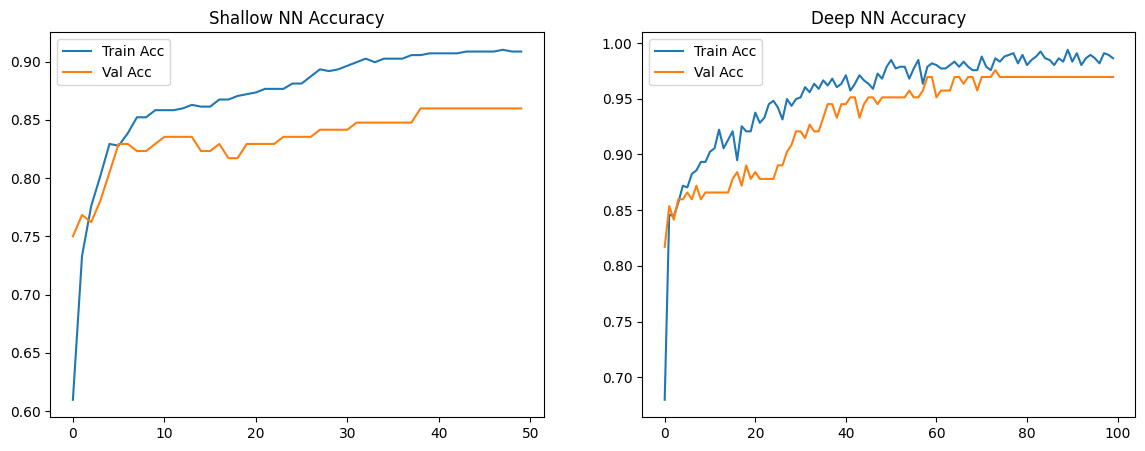

In [39]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].plot(shallow_history['train_acc'],label='Train Acc')
ax[0].plot(shallow_history['val_acc'],label='Val Acc')
ax[0].set_title('Shallow NN Accuracy')
ax[0].legend()

ax[1].plot(deep_history['train_acc'],label='Train Acc')
ax[1].plot(deep_history['val_acc'],label='Val Acc')
ax[1].set_title('Deep NN Accuracy')
ax[1].legend()

plt.show()

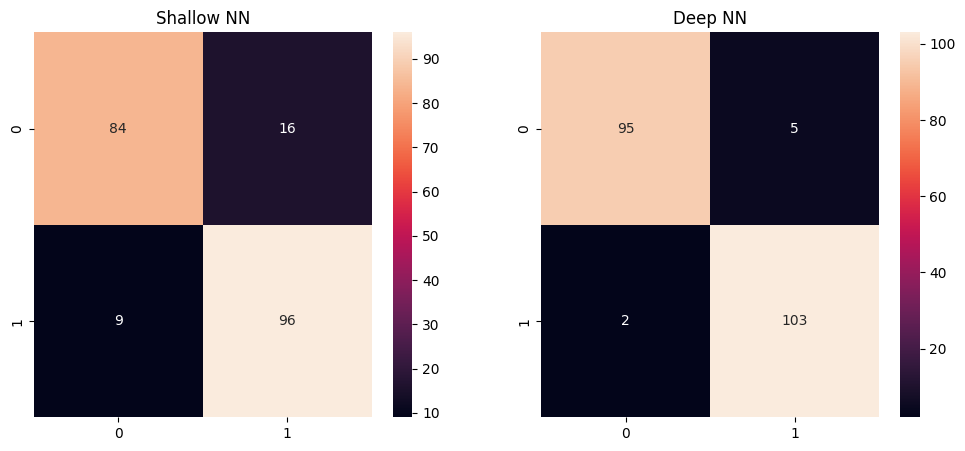

In [40]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    shallow_results['cm'],
    annot=True,
    fmt='d',
    ax=ax[0]
)

ax[0].set_title('Shallow NN')

sns.heatmap(
    deep_results['cm'],
    annot=True,
    fmt='d',
    ax=ax[1]
)

ax[1].set_title('Deep NN')

plt.show()

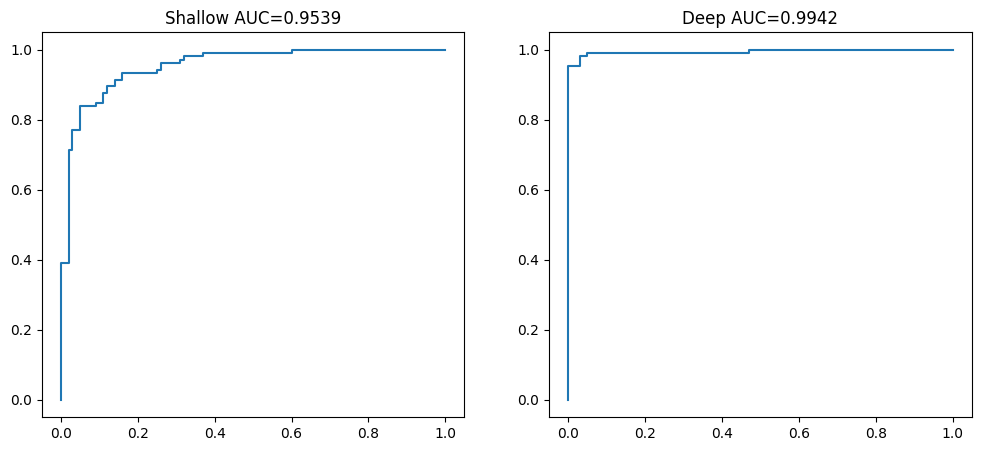

In [41]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

fpr,tpr,_ = roc_curve(
    y_test,
    shallow_results['probs']
)

ax[0].plot(fpr,tpr)

ax[0].set_title(
    f"Shallow AUC={shallow_results['auc']:.4f}"
)

fpr,tpr,_ = roc_curve(
    y_test,
    deep_results['probs']
)

ax[1].plot(fpr,tpr)

ax[1].set_title(
    f"Deep AUC={deep_results['auc']:.4f}"
)

plt.show()

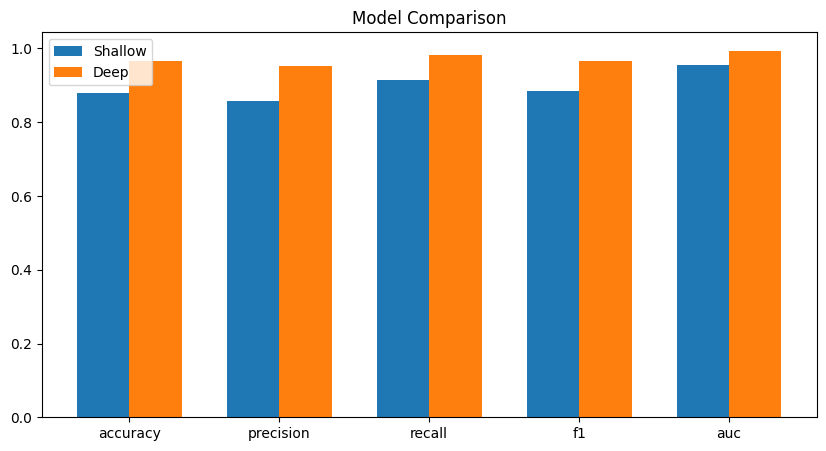

In [42]:
metrics = ['accuracy',
           'precision',
           'recall',
           'f1',
           'auc']

shallow_values = [
    shallow_results[m]
    for m in metrics
]

deep_values = [
    deep_results[m]
    for m in metrics
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    shallow_values,
    width,
    label='Shallow'
)

plt.bar(
    x+width/2,
    deep_values,
    width,
    label='Deep'
)

plt.xticks(x,metrics)

plt.legend()

plt.title("Model Comparison")

plt.show()

In [43]:
print("SHALLOW MODEL")

print(shallow_model)

summary(
    shallow_model,
    (input_dim,)
)

SHALLOW MODEL
ShallowNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]             448
              ReLU-2                   [-1, 32]               0
            Linear-3                    [-1, 1]              33
           Sigmoid-4                    [-1, 1]               0
Total params: 481
Trainable params: 481
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [44]:
print("DEEP MODEL")

print(deep_model)

summary(
    deep_model,
    (input_dim,)
)

DEEP MODEL
DeepNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           1,792
              ReLU-2                  [-1, 128]               0
           Dropout-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
              ReLU-5                   [-1, 64]               0
           Dropout-6                   [-1, 64]               0
            Linear-7                   [-1, 32]        